In [1]:
import sys 

sys.path.append("../../src/")
from project_imports import *



In [ ]:
cos()

array([0.03141593, 0.09424778, 0.15707963, 0.21991149, 0.28274334,
       0.34557519, 0.40840704, 0.4712389 , 0.53407075, 0.5969026 ,
       0.65973446, 0.72256631, 0.78539816, 0.84823002, 0.91106187,
       0.97389372, 1.03672558, 1.09955743, 1.16238928, 1.22522113,
       1.28805299, 1.35088484, 1.41371669, 1.47654855, 1.5393804 ,
       1.60221225, 1.66504411, 1.72787596, 1.79070781, 1.85353967,
       1.91637152, 1.97920337, 2.04203522, 2.10486708, 2.16769893,
       2.23053078, 2.29336264, 2.35619449, 2.41902634, 2.4818582 ,
       2.54469005, 2.6075219 , 2.67035376, 2.73318561, 2.79601746,
       2.85884931, 2.92168117, 2.98451302, 3.04734487, 3.11017673])

In [2]:
#### What I want to do first is be able to set eigenstates.

L = 100

k = 2*pi*(np.arange(0,L//2)+1/2)/L
uk=  sin(k/2)#cos(pi/4-k/4)
vk = 1j*cos(k/2)#1j*sin(pi/4-k/4)

uk = cos(pi/4-k/4)
vk = 1j*sin(pi/4-k/4)
#uk = np.zeros(len(k))
#vk = np.ones(len(k))

lower_states= [ array([u,v]) for u,v in zip(uk,vk)]
upper_states= [ array([v,u]) for u,v in zip(uk,vk)]

def state(alphas,betas):
    states=[]
    for lower_state_k, upper_state_k, alpha_k, beta_k in zip(lower_states,upper_states,alphas,betas):
        state_k = alpha_k * lower_state_k + beta_k * upper_state_k
        states.append(state_k)
    return states



In [3]:
#Test

alphas = np.ones(len(k))
betas = np.zeros(len(k))
s = state(alphas,betas)
e = state(betas,alphas)
#s= state(alphas*sqrt(1/2),alphas*sqrt(1/2))

In [4]:
phase= exp(1j*k)

In [5]:
def BA(k,r,states, states2=None):
    ba = [ba(ki,r) for ki in k]
    data=[]
    if states2 == None:
        for bi, si in zip(ba,states):
            data.append(np.vdot(si,bi@si))
    else:
        for bi,si,fi in zip(ba,states,states2):
            data.append(np.vdot(si,bi@fi))
    return np.average(array(data))

In [ ]:

def AA(r):
    return [aa*exp(1j*ki*r) for ki in k]



In [22]:
# In this 2×2 (|0_k>,|1_k>) sector representation, a consistent choice that
# matches the Majorana algebra is:
#
# <A_0 A_r>  ~  (1/L) Σ_k e^{+i k r}  (up to conventions)
# <B_0 B_r>  ~  (1/L) Σ_k e^{-i k r}
#
# In your matrix basis, the identity is (ac+ca) and the "phase-rotation"
# generator is (aa-cc). Using cos/sin gives real-valued r-Fourier weights.

I2 = ac + ca              # 2×2 identity in this basis
J  = aa - cc              # [[0,1],[-1,0]]

def aa(ki, r):
    """Operator whose expectation (avg over k) gives <A_0 A_r> in your convention."""
    return ( 2*np.cos(ki*r)*I2 + 2j*np.sin(ki*r)*J )/2

def bb(ki, r):
    """Operator whose expectation (avg over k) gives <B_0 B_r> in your convention."""
    return ( 2*np.cos(ki*r)*I2 - 2j*np.sin(ki*r)*J )/2

# Verification (same style as your BA test)
aa0 = [aa(ki, 0) for ki in k]
aa1 = [aa(ki, 1) for ki in k]
aa2 = [aa(ki, 2) for ki in k]

bb0 = [bb(ki, 0) for ki in k]
bb1 = [bb(ki, 1) for ki in k]
bb2 = [bb(ki, 2) for ki in k]

AA0,AA1,AA2 = [],[],[]
BB0,BB1,BB2 = [],[],[]

for si, A0,A1,A2, B0,B1,B2 in zip(s, aa0,aa1,aa2, bb0,bb1,bb2):
    AA0.append(np.vdot(si, A0 @ si))
    AA1.append(np.vdot(si, A1 @ si))
    AA2.append(np.vdot(si, A2 @ si))

    BB0.append(np.vdot(si, B0 @ si))
    BB1.append(np.vdot(si, B1 @ si))
    BB2.append(np.vdot(si, B2 @ si))

AA0,AA1,AA2 = map(lambda x: np.average(np.array(x)), (AA0,AA1,AA2))
BB0,BB1,BB2 = map(lambda x: np.average(np.array(x)), (BB0,BB1,BB2))

print("AA(r=0,1,2) =", AA0, AA1, AA2)
print("BB(r=0,1,2) =", BB0, BB1, BB2)

AA(r=0,1,2) = (1+0j) (-0.42446555200908676+0j) (-0.16987004969499603+0j)
BB(r=0,1,2) = (1+0j) (0.4244655520090869+0j) (0.16987004969499592+0j)


In [27]:
import kblock_ising_model as kb
k = kb.k_vals(100)
U = kb.U(k,0)

kb.AA([U,k,1])

np.complex128(-1.7763568394002505e-17j)

In [ ]:
aa = array([[0,1],[0,0]])
cc = array([[0,0],[1,0]])
ca = array([[0,0],[0,1]])
ac = array([[1,0],[0,0]])

sx = [-2*cos(ki)*ac-aa*2*1j*sin(ki)+2*1j*sin(ki)*cc+2*cos(ki)*ca for ki in k]

sz = [2*ac-2*ca for ki in k]
def ba(ki, r):
    return (
        -2*np.cos(ki*r)*ac
        +2*np.cos(ki*r)*ca
        -2j*np.sin(ki*r)*aa
        +2j*np.sin(ki*r)*cc
    )/2
# Verification Tests:
ba0 = [ba(ki, 0) for ki in k]
ba1 = [ba(ki, 1) for ki in k]
ba2 = [ba(ki, 2) for ki in k]

dat0=[]
dat1=[]
dat2=[]
for si, ei,b0,b1,b2 in zip(s,e,ba0,ba1,ba2):
    dat0.append( np.vdot(si,b0@si))
    dat1.append( np.vdot(si,b1@si))
    dat2.append( np.vdot(si,b2@si))
dat0=np.average(array(dat0))
dat1=np.average(array(dat1))
dat2=np.average(array(dat2))

x1 = dat1
x2 = dat1**2- dat0*dat2

print(x1)
print(x2)

(0.6366459530600056+0j)
(0.540468551799933+0j)


In [7]:
data=[]
data2=[]
for i in range(len(k)):
    at, bt = alphas.copy(), betas.copy()
    at[i]=0
    bt[i]=1

    s = state(at,bt)
    dat0=[]
    dat1=[]
    dat2=[]
    for si,b0,b1,b2 in zip(s,ba0,ba1,ba2):
        dat0.append( np.vdot(si,b0@si))
        dat1.append( np.vdot(si,b1@si))
        dat2.append( np.vdot(si,b2@si))
    dat0=np.average(array(dat0))
    dat1=np.average(array(dat1))
    dat2=np.average(array(dat2))
    x1 = dat1
    x2 = dat1**2- dat0*dat2
    data.append(x1)
    data2.append(x2)


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


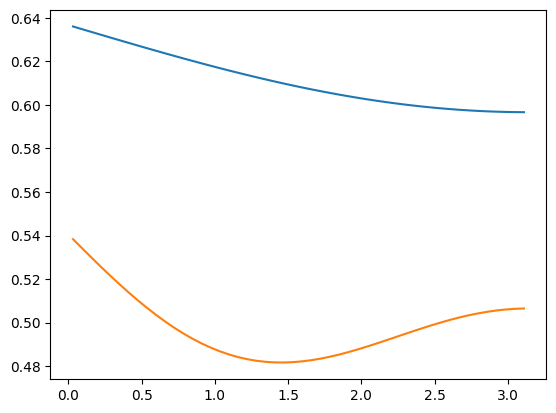

In [8]:
plot(k,data)
plot(k,data2)

In [9]:

################################################
#                   IMPORTS
################################################
from project_imports import * 
################################################
#           HELPFUL FUNCTIONS
################################################
def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def Pfaffian(M):
    """
    Compute the Pfaffian of an antisymmetric matrix M.
    M must be (2N x 2N) and antisymmetric.
    ChatGPT wrote this....
    """
    M = np.array(M, dtype=complex)
    n = M.shape[0]

    if n % 2 != 0:
        return 0.0

    pf = 1.0 + 0j
    A = M.copy()

    for k in range(0, n-1, 2):
        # find a nonzero pivot
        if abs(A[k, k+1]) < 1e-14:
            swap_found = False
            for l in range(k+2, n):
                if abs(A[k, l]) > 1e-14:
                    # swap columns k+1 and l
                    A[:, [k+1, l]] = A[:, [l, k+1]]
                    A[[k+1, l], :] = A[[l, k+1], :]
                    pf *= -1
                    swap_found = True
                    break
            if not swap_found:
                return 0.0

        pf *= A[k, k+1]

        for i in range(k+2, n):
            for j in range(i+1, n):
                A[i, j] -= (
                    A[k, i]*A[k+1, j] - A[k, j]*A[k+1, i]
                ) / A[k, k+1]
                A[j, i] = -A[i, j]

    return pf
def D(N,states,states2=None):
    """Using Definition in 4.72 of Sachdev.
    
    N = i-j+1 but we will also set i = 0 and j=n so 
    N = 1-n"""
    n = 1-N

    return BA(n,states,states2)

In [10]:
def BA(r,states, states2=None):
    b = [ba(ki,r) for ki in k]
    data=[]
    if states2 == None:
        for bi, si in zip(b,states):
            data.append(np.vdot(si,bi@si))
    else:
        for bi,si,fi in zip(b,states,states2):
            data.append(np.vdot(si,bi@fi))
    return np.average(array(data))

from joblib import Parallel, delayed
import numpy as np

# def BA(r, states, states2=None):
#     n_jobs=-1
#     b = [ba(ki, r) for ki in k]

#     if states2 is None:
#         data = Parallel(n_jobs=n_jobs)(
#             delayed(np.vdot)(si, bi @ si)
#             for bi, si in zip(b, states)
#         )
#     else:
#         data = Parallel(n_jobs=n_jobs)(
#             delayed(np.vdot)(si, bi @ fi)
#             for bi, si, fi in zip(b, states, states2)
#         )

#     return np.average(np.array(data))

In [11]:

alphas = np.ones(len(k))
betas = np.zeros(len(k))
s = state(alphas,betas)

a2= alphas.copy()
b2= betas.copy()
b2[1]=1
a2[1]=0
s2= state(a2,b2)
sigma_general([0,1],s,s2)

NameError: name 'sigma_general' is not defined

In [12]:
def sigma_general(indices,states,states2=None):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = D(Nd,states,states2)
    return np.linalg.det(C)

def P_n(n,state,state2=None):
    even= True 
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices,state,state2)))*degen)
        else:
            dat.append(sigma_general(indices,state,state2)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n


In [ ]:
def sigma_general(indices,state):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Get string lengths
    A_coords = np.array(indices)
    B_coords = np.array(indices)
    N = len(indices)
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = kz.D(-Nd,state)
   # print(C)
    return np.linalg.det(C)

In [13]:
def P_n_plot(n,excite_prob):
    #Diagonal <Psi_k | P |Psi_k>
    data=[]
    for i in range(len(k)):
        at, bt = alphas.copy(), betas.copy()
        at[i]=1-sqrt(excite_prob)
        bt[i]=excite_prob

        s = state(at,bt)

        data.append(P_n(n,s))
    return array(data)

def sx_plot(r,excite_prob):
    #Diagonal <Psi_k | P |Psi_k>
    data=[]
    for i in range(len(k)):
        at, bt = alphas.copy(), betas.copy()
        at[i]=1-sqrt(excite_prob)
        bt[i]=excite_prob

        s = state(at,bt)

        data.append(sigma_general([0,r],s))
    return array(data)

In [14]:
from joblib import Parallel, delayed
import numpy as np

rs = np.arange(1, 20)

data = Parallel(n_jobs=-1)(
    delayed(sx_plot)(r, 1) for r in rs
)

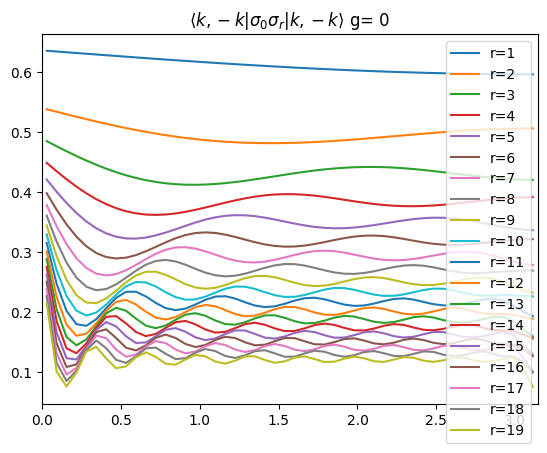

In [15]:
for d,r in zip(data,rs):
    plot(k,d,label=f"r={r}")
title(r"$\langle k, -k | \sigma_0 \sigma_r |k,-k \rangle$ g= 0")
xlim(0,pi)
legend()

In [783]:
betas

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

# Off Diaogonal elements

In [17]:
def P_n_plot_OD(n,excite_prob):
    #Diagonal <Psi_k | P |Psi_k>
    data=[]
    
    for i in range(len(k)):
        at, bt = alphas.copy(), betas.copy()
        at[i]=1-sqrt(excite_prob)
        bt[i]=excite_prob

        s = state(at,bt)

        gs = state(alphas,betas)

        data.append(P_n(n,s,gs))
    return array(data)

def sx_plot_OD(r,excite_prob):
    data=[]
    for i in range(len(k)):
        at, bt = alphas.copy(), betas.copy()
        at[i]=1-sqrt(excite_prob)
        bt[i]=excite_prob

        s = state(at,bt)
        gs= state(alphas,betas)
        data.append(sigma_general([0,r],s,gs))
    return array(data)

100%|██████████| 3/3 [00:00<00:00, 21.07it/s]


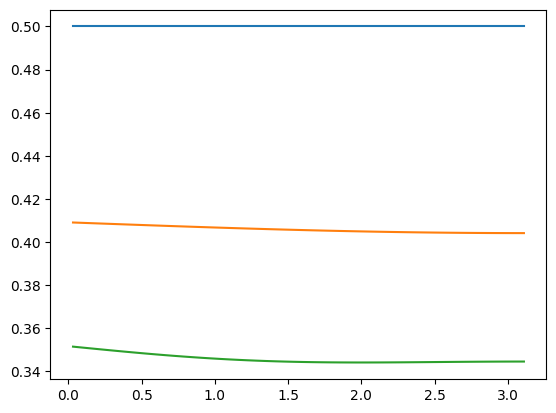

In [18]:
for n in tqdm(np.arange(1,4)):
    plot(k,P_n_plot_OD(n,1))

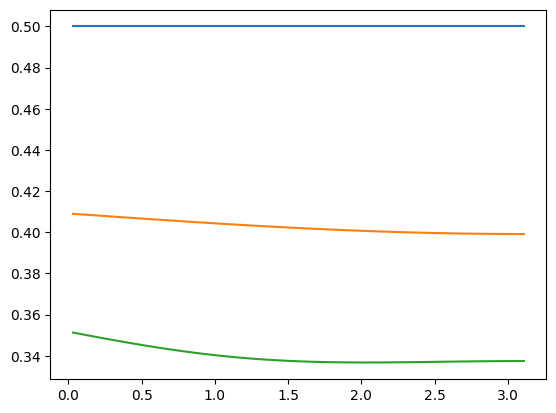

In [823]:
for n in np.arange(1,4):
    plot(k,P_n_plot(n,1))

In [824]:
def P_n_plot_OO(n,excite_prob,j):
    #Diagonal <Psi_k | P |Psi_k>
    data=[]
    
    for i in range(len(k)):
        at, bt = alphas.copy(), betas.copy()
        at[i]=1-sqrt(excite_prob)
        bt[i]=excite_prob

        s = state(at,bt)

        a2,b2= alphas.copy(),betas.copy()
        a2[j]=1-sqrt(excite_prob)
        b2[j]= excite_prob
        s2= state(a2,b2)

        data.append(P_n(n,s,s2))
    return array(data)

100%|██████████| 5/5 [00:01<00:00,  4.01it/s]


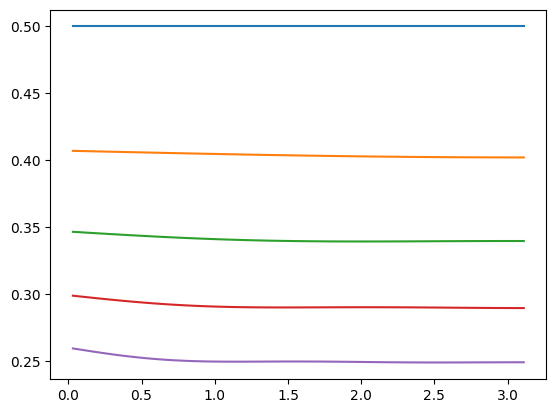

In [832]:
for n in tqdm(np.arange(1,6)):
    plot(k,P_n_plot_OO(n,1,L//8))

100%|██████████| 7/7 [00:09<00:00,  1.42s/it]


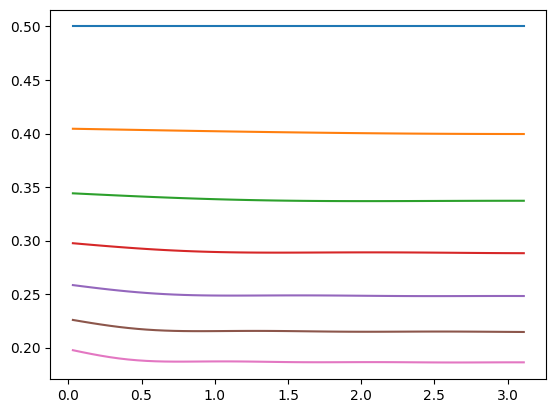

In [835]:
for n in tqdm(np.arange(1,8)):
    plot(k,P_n_plot_OO(n,1,L*3//8))

In [ ]:

################################################
#           Z Operators
################################################
def sz_correlation(indices,state):
    """
    Computes the correlation of a string of sigma_x operators at sites labeled by indices. 
    This code commutes them into an ordered form (sigma_i<sigma_j<..)
    Then evaluates the expectation through the use of Majorana Fermions
    """
    #Remove Duplicates, sort (allowed via commutation algebra and sigma^2=1)
    indices = list(set(indices))
    #Create full Majorna String
    Majorana_String = Create_Majorana_Strings_Z(indices)
    #Create full Covariance Matrix
    Majorana_cov = Majorana_Covariance(Majorana_String,state)
    #Evaluate expectation with Pfaffian
    return Pfaffian(Majorana_cov)
    
def Pz_n(n,state):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
        a = array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    

    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        dat.append(sz_correlation(indices,state)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n